In [10]:
import os, random, numpy as np, pandas as pd
from tqdm.auto import tqdm
import torch, torch.backends.cudnn as cudnn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 自動判斷 Colab 或本機
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = "/content/drive/MyDrive"
    print("Running on Google Colab")
except ImportError:
    BASE_DIR = os.getcwd()
    print("Running locally")

DATA_DIR = os.path.join(BASE_DIR, "crops_image")
OUTPUT_DIR = os.path.join(BASE_DIR, "cnn_runs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

Running locally


##**Enabling and testing the GPU on Google Colab**

In [11]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

False
0


In [12]:
if torch.cuda.is_available():
    !nvidia-smi

# **Step1: Data Preparation**
## 1. Load The Dataset


In [13]:
base_dir = DATA_DIR # 設定資料集的根目錄路徑
filepath = [] # 用來存每張圖片的完整路徑
classes = [] # 用來存每張圖片的「類別名稱」
# 列出 base_dir 裡的所有資料夾名稱，逐一取出當作 class_name
for class_name in tqdm(os.listdir(base_dir), desc="Loading Data..."):
  class_dir = os.path.join(base_dir, class_name) # 把根目錄和類別名稱合併成完整資料夾路徑
  # 確認這個路徑是否真的是資料夾
  if os.path.isdir(class_dir):
    # 列出這個類別資料夾底下的所有檔案
    for filename in os.listdir(class_dir):
      # 把這張圖片的完整路徑加入 filepath list
      filepath.append(os.path.join(class_dir, filename))
      # 把這張圖片的類別名稱加入 classes list
      # 這樣 filepath[i] 與 classes[i] 就一一對應
      classes.append(class_name)

df = pd.DataFrame({
  "filepath": filepath, # 每張圖片的檔案路徑
  "class": classes # 每張圖片的標籤（類別）
})
print("\n", df.sample(5)) # 隨機抽取 5 筆資料，檢查 DataFrame 是否正確
print(f"Total classes: {len(df)//300}")
print(f"Total images: {len(df)}")


Loading Data...: 100%|██████████| 11/11 [00:00<00:00, 833.18it/s]


                                                filepath     class
239   c:\Users\USERYA\Desktop\pythonGit\crop-image-c...   atemoya
2272  c:\Users\USERYA\Desktop\pythonGit\crop-image-c...     mango
740   c:\Users\USERYA\Desktop\pythonGit\crop-image-c...  bareland
2576  c:\Users\USERYA\Desktop\pythonGit\crop-image-c...    papaya
2370  c:\Users\USERYA\Desktop\pythonGit\crop-image-c...     mango
Total classes: 11
Total images: 3300


In [14]:
# from google.colab import drive
# drive.mount('/content/drive')

## 2. Data Splitting

In [15]:
# 設定比例：訓練80%，測試20%
ratio = 0.8
# 在 DataFrame df 新增一個欄位 phase，一開始先填空字串。
# 這個欄位用來標記圖片是屬於「train」還是「test」
df['phase'] = ''

# 迴圈跑過每一個類別（用 unique() 取得不重複的類別名）
for class_name in tqdm(df['class'].unique(), desc="Splitting Datasets..."):
    # 從整個 DataFrame 選出屬於該類別的資料（每類 300 筆）
    class_df = df[df['class'] == class_name]

    # train_idx: 隨機抽 80% 當訓練, test_idx: 剩下 20% 當測試
    # 這裡是「分開對每個類別切」，所以能保證 每個類別的訓練/測試數量都符合比例。
    train_idx, test_idx = train_test_split(
        class_df.index,
        train_size=ratio,
        shuffle=True, # 先隨機打亂再分
        random_state=42 # 設定隨機種子，讓結果可重現
    )

    # 在原本的 df 裡，依照索引標記這筆資料是 train 或 test。
    # 這樣每張圖片就有了「路徑、類別、phase(train/test)」三個資訊。
    df.loc[train_idx, 'phase'] = 'train'
    df.loc[test_idx, 'phase'] = 'test'

# print("\n", df[df['class'] == "mango"].sample(10))
print(df['phase'].value_counts())


Splitting Datasets...: 100%|██████████| 11/11 [00:00<00:00, 356.72it/s]

phase
train    2640
test      660
Name: count, dtype: int64


## 3. PyTorch Dataset & DataLoader

In [16]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image # 用來讀圖片
from torchvision import transforms

# 把類別依字母排序，確保固定順序
classes_sorted = sorted(df['class'].unique().tolist())
# 把 類別名稱 對應到 數字編號
class_to_idx = {c:i for i, c in enumerate(classes_sorted)}
# 反轉字典，把 數字編號 → 類別名稱
idx_to_class = {i:c for c,i in class_to_idx.items()}
print("class_to_idx =", class_to_idx)

# Transforms：訓練集(含增強)
IMG_SIZE = 224

# 建立訓練集用的transforms
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)), # 隨機裁切並縮放到 224×224
    transforms.RandomHorizontalFlip(p=0.5), # 以 50% 機率做水平翻轉
    transforms.RandomRotation(15), # 隨機旋轉 ±15 度
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15), # 隨機調整亮度、對比、飽和度，各幅度 0.15。
    transforms.ToTensor(), # 把 PIL 影像轉成張量，並把像素縮放到 [0,1]
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]), # 標準化
])

# 建立測試集用的transforms
test_tfms = transforms.Compose([
    transforms.Resize(256), # 把最短邊縮放到 256
    transforms.CenterCrop(IMG_SIZE), # 中心裁切成 224×224
    transforms.ToTensor(), # 轉成張量、縮放到 [0,1]
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]), # 標準化
])

df_train = df[df['phase'] == 'train'].reset_index(drop=True) # 從 df 篩出訓練資料並重置索引
df_test  = df[df['phase'] == 'test'].reset_index(drop=True) # 從 df 篩出測試資料並重置索引

# 自訂Dataset
class CropsDataset(Dataset):
    def __init__(self, df_split, tfms, class_to_idx):
        self.filepaths = df_split['filepath'].to_list() # 把檔案路徑欄轉成list存起來
        self.labels    = [class_to_idx[c] for c in df_split['class'].to_list()] # 把類別字串依映射轉成整數標籤清單
        self.tfms = tfms

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        fp = self.filepaths[idx] # 根據索引讀取圖片
        try:
            img = Image.open(fp).convert('RGB') # 開啟影像並轉成 RGB 三通道
        except Exception as e:
            raise RuntimeError(f"Failed to open image: {fp}\n{e}") # 若失敗，丟出錯誤並標記是哪個檔案
        x = self.tfms(img) if self.tfms is not None else img # 若有設定轉換，對影像套用；否則保留原影像
        y = torch.tensor(self.labels[idx], dtype=torch.long) # 把對應的整數標籤轉成 long 型別張量
        return x, y

# 建立 DataLoader
BATCH_SIZE = 32 # 設定每個批次含 32 張影像
NUM_WORKERS = 0

train_ds = CropsDataset(df_train, train_tfms, class_to_idx) # 訓練集
test_ds  = CropsDataset(df_test,  test_tfms,  class_to_idx) # 測試集

# 訓練集 DataLoader
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
# 測試集 DataLoader
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# 驗證
xb, yb = next(iter(train_loader))
print("train batch:", xb.shape, yb.shape)  # [32, 3, 224, 224], [32]


class_to_idx = {'atemoya': 0, 'banana': 1, 'bareland': 2, 'cabbage': 3, 'carrot': 4, 'grapes': 5, 'guava': 6, 'mango': 7, 'papaya': 8, 'pineapple': 9, 'pumpkin': 10}


c:\Users\USERYA\Desktop\pythonGit\crop-image-classification-cnn\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


train batch: torch.Size([32, 3, 224, 224]) torch.Size([32])


# **Step2: Build CNN Model**

In [18]:
import torch.nn as nn # PyTorch 的神經網路模組
import torch.nn.functional as F # 函式型態的神經網路工具

num_classes = len(classes_sorted) # 類別數

# 定義一個繼承自 nn.Module 的自建 CNN 類別
class MyCNN(nn.Module):
    """
    自建 CNN：
    - 4 個卷積區塊：Conv(3x3, padding=1) → BN(正規化) → ReLU(非線性) → MaxPool(降維，保留特徵，忽略複雜背景)
    - 通道數: 3→32→64→128→256
    """
    def __init__(self, num_classes):
        super().__init__() # constructor，呼叫父類別初始化

        # 第一個卷積區塊
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 輸入 3 通道（RGB），輸出 32 通道；padding=1 使空間大小不變
            nn.BatchNorm2d(32), # 正規化每個 batch 的特徵，讓訓練更穩
            nn.ReLU(inplace=True), # 非線性激活
            nn.MaxPool2d(2)  # 長寬各除以 2（224→112）
        )

        # 第二個卷積區塊：通道升到 64，再池化到 56×56
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)  # 112 -> 56
        )

        # 第三個卷積區塊：通道 128，空間 28×28
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)  # 56 -> 28
        )

        # 第四個卷積區塊：通道 256，空間 14×14
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)  # 28 -> 14
        )

        # 全域平均池化到 1x1，通道數維持 256
        self.gap = nn.AdaptiveAvgPool2d(1)   # [B,256,14,14] -> [B,256,1,1]
        # 以0.5機率隨機遮蔽神經元，降低過擬合
        self.dropout = nn.Dropout(p=0.5)
        # 線性分類器：將 256 維的特徵 → 對應到 num_classes 個輸出（例如 11 個水果類別）
        self.fc = nn.Linear(256, num_classes)

        # 輕量初始化：讓初期更穩
        for m in self.modules():
          if isinstance(m, nn.Conv2d):
              nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
              if m.bias is not None: nn.init.zeros_(m.bias)
          elif isinstance(m, nn.BatchNorm2d):
              nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
          elif isinstance(m, nn.Linear):
              nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    # 依序通過四個卷積區塊。
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x) # 全域平均池化，將空間尺寸壓縮為 1×1
        x = x.view(x.size(0), -1) # 扁平化通道：把 [B,256,1,1] 攤平成 [B,256]。
        x = self.dropout(x) # 在分類器前做一次 Dropout，增強泛化
        x = self.fc(x)
        return x


In [19]:
import torch  # 匯入 PyTorch 主套件
import torch.nn as nn  # 匯入神經網路模組並取別名 nn

class ResidualBlock(nn.Module):  # 定義名為 ResidualBlock 的類別，繼承自 nn.Module（可用於模型組合）
    """簡單的 Residual Block：兩層 conv + BN + ReLU，支援通道改變"""

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()  # 呼叫父類別的建構子以初始化 nn.Module 相關狀態
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1),  # 3x3 卷積，padding=1 以保持在 stride=1 時的空間大小
            nn.BatchNorm2d(out_ch),  # 批次正規化（BatchNorm）以穩定訓練與加速收斂
            nn.ReLU(inplace=True),  # ReLU 啟用函數，inplace=True 表示在原張量上就地運算以節省記憶體
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),  # 第二層 3x3 卷積，保持通道數不變
            nn.BatchNorm2d(out_ch)  # 第二層卷積後的 BatchNorm
        )

        self.skip = nn.Sequential()  # 預設的 skip（捷徑）為恆等（空的 Sequential，直接回傳輸入）
        if in_ch != out_ch or stride != 1:  # 若輸入/輸出通道不同或 stride 不是 1，則需要用 1x1 conv 去調整捷徑
            self.skip = nn.Sequential(  # 設定捷徑為 1x1 卷積（調整通道與空間大小）加上 BN
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride),  # 1x1 卷積：改變通道數並支援下採樣（由 stride 控制）
                nn.BatchNorm2d(out_ch)  # 捷徑路徑的 BatchNorm
            )

    def forward(self, x):  # 定義前向傳播：接收輸入張量 x
        return nn.ReLU(inplace=True)(self.conv(x) + self.skip(x))  # 主路徑與捷徑相加（residual connection），再套用 ReLU 後回傳結果


class MyCNN2(nn.Module):  # 定義 MyCNN2 類別，繼承自 nn.Module
    """
    改良版 MyCNN：
    - VGG-style 卷積堆疊（每個 block 兩層卷積）
    - Strided Conv 替代 MaxPool
    - 簡單 Skip Connection
    """

    def __init__(self, num_classes):
        super().__init__()  # 呼叫父類別建構子初始化模組
        self.block1 = ResidualBlock(3, 32, stride=2)   # 第一個 block：3->32，stride=2（空間寬高縮半，例如 224->112）
        self.block2 = ResidualBlock(32, 64, stride=2)  # 第二個 block：32->64，stride=2（112->56）
        self.block3 = ResidualBlock(64, 128, stride=2) # 第三個 block：64->128，stride=2（56->28）
        self.block4 = ResidualBlock(128, 256, stride=2)# 第四個 block：128->256，stride=2（28->14）

        self.gap = nn.AdaptiveAvgPool2d(1) # 全域平均池化（Global Average Pooling）到 1x1，輸出形狀 [B, C, 1, 1]
        self.dropout = nn.Dropout(0.5)  # Dropout，丟棄率 0.5（訓練時降低過擬合）
        self.fc = nn.Linear(256, num_classes)  # 最後的全連接層：將 256 維特徵映射到 num_classes 個 logits

        # 初始化
        for m in self.modules():
            if isinstance(m, nn.Conv2d):  # 若模組是 Conv2d
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')  # 使用 Kaiming 正態初始化（適合 ReLU）
                if m.bias is not None: nn.init.zeros_(m.bias)  # 若 Conv 有 bias，初始化為 0
            elif isinstance(m, nn.BatchNorm2d):  # 若模組是 BatchNorm2d
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)  # BN 的 scale(weight) 設為 1，shift(bias) 設為 0
            elif isinstance(m, nn.Linear):  # 若模組是 Linear（全連接層）
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)  # Linear 權重小常態分配、bias 設為 0

    def forward(self, x):
        x = self.block1(x)  # 經過第一個 Residual block（輸出通道 32）
        x = self.block2(x)  # 經過第二個 Residual block（輸出通道 64）
        x = self.block3(x)  # 經過第三個 Residual block（輸出通道 128）
        x = self.block4(x)  # 經過第四個 Residual block（輸出通道 256）
        x = self.gap(x)  # 全域平均池化，變成 [B, 256, 1, 1]
        x = x.view(x.size(0), -1)  # 攤平成 [B, 256] （batch size 維度保留，其他壓平）
        x = self.dropout(x)  # 套用 dropout
        x = self.fc(x)  # 全連接層得到 logits
        return x

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 檢查目前環境是否有 GPU

# 建立一個 MyCNN 模型，指定類別數（num_classes）
model = MyCNN2(num_classes=num_classes).to(device) # .to(device) → 把模型所有權重搬到剛剛設定的裝置（GPU 或 CPU）
# 印出模型結構，確認層級是否正確（會看到 Conv2d → BatchNorm → ReLU → MaxPool 的堆疊，最後接 Dropout+Linear）。
print(model)

# ---- 快速 sanity check：用你前面抽到的 batch xb 驗證輸出形狀 ----
with torch.no_grad():
    xb_dev = xb.to(device)  # xb 來自前面 next(iter(train_loader))
    out = model(xb_dev)
    print("logits shape:", out.shape)  # [BATCH_SIZE, num_classes]

MyCNN2(
  (block1): ResidualBlock(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (skip): Sequential(
      (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (block2): ResidualBlock(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): Batc

# **Step3: Train the Model**

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import copy, time
import torchvision.transforms.functional as TF

# 自定義 Loss Function：部分類別做 Label Smoothing
class PartialLabelSmoothingLoss(nn.Module):
    def __init__(self, num_classes, smooth_eps=0.1, smooth_classes=None):
        super().__init__()  # 初始化父類別
        self.num_classes = num_classes  # 總類別數
        self.smooth_eps = smooth_eps  # 平滑參數
        self.smooth_classes = smooth_classes if smooth_classes else []  # 需要平滑的類別列表

    def forward(self, preds, targets):
        with torch.no_grad():  # 建立 one-hot 真實分布，不參與梯度
            true_dist = torch.zeros_like(preds)  # 建立與 preds 相同大小的零張量
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0)  # 對應標籤的位置設為 1 (one-hot encoding)

            # 僅對指定的類別進行 Label Smoothing
            for i, t in enumerate(targets):
                if t.item() in self.smooth_classes:  # 如果這個 target 類別在指定平滑清單中
                    true_dist[i] = (1 - self.smooth_eps) * true_dist[i] \
                                   + self.smooth_eps / (self.num_classes - 1)  # label smoothing 分布

        # Cross Entropy：sum(-p*logq)，再取 batch 平均
        loss = torch.mean(torch.sum(-true_dist * F.log_softmax(preds, dim=1), dim=1))
        return loss

# 損失、優化器、LR排程器
# criterion = nn.CrossEntropyLoss()
criterion = PartialLabelSmoothingLoss(num_classes=11, smooth_eps=0.1, smooth_classes=[5,7,8]) # mango,grape,papaya做LabelSmoothing
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

# accuracy、train_one_epoch、evaluate
def accuracy_from_logits(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

# 單輪訓練函數
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # 設定為訓練模式
    loss_sum, acc_sum, n_batches = 0.0, 0.0, 0  # 初始化統計值
    for xb, yb in tqdm(loader, desc="Training", leave=False):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)  # 移動到 GPU
        optimizer.zero_grad(set_to_none=True)  # 清空梯度
        logits = model(xb)  # 前向傳播
        loss = criterion(logits, yb)  # 計算 loss
        loss.backward()  # 反向傳播
        optimizer.step()  # 更新參數
        loss_sum += loss.item()  # 累積 loss
        acc_sum  += accuracy_from_logits(logits, yb)  # 累積 accuracy
        n_batches += 1  # batch 計數
    return loss_sum/n_batches, acc_sum/n_batches

@torch.no_grad()
# Test Time Augmentation(TTA) 評估函數
def tta_evaluate(model, loader, criterion, device, tta_transforms=None, collect=False):
    """
    - loader: 測試集 DataLoader
    - tta_transforms: list of transform functions，對輸入影像做增強
    - collect: 是否要收集所有預測與標籤 (方便後續算 confusion matrix)
    """
    model.eval()  # 設為測試模式
    loss_sum, acc_sum, n_batches = 0.0, 0.0, 0  # 初始化
    all_y, all_p = [], []

    for xb, yb in tqdm(loader, desc="TTA Evaluating", leave=False):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)  # 移到 GPU

        if tta_transforms is None:  # 如果沒有定義 TTA，就直接跑
            logits = model(xb)
        else:
            logits_list = []  # 存每個增強版本的輸出
            for tfm in tta_transforms:
                xb_aug = tfm(xb)  # 對整個 batch 做增強
                logits_list.append(model(xb_aug))  # 模型輸出
            logits = torch.stack(logits_list).mean(0)  # 對 logits 取平均 (集成效果)

        loss = criterion(logits, yb)  # 計算 loss
        loss_sum += loss.item()
        acc_sum += accuracy_from_logits(logits, yb)  # 計算 acc
        n_batches += 1

        if collect:
            all_y.append(yb.cpu().numpy())  # 真實
            all_p.append(logits.argmax(1).cpu().numpy())  # 預測

    avg_loss, avg_acc = loss_sum / n_batches, acc_sum / n_batches  # 取平均

    if collect:
        return avg_loss, avg_acc, np.concatenate(all_y), np.concatenate(all_p)
    return avg_loss, avg_acc  # 否則只回傳 loss 和 acc

def evaluate(model, loader, criterion, device, collect=False):
    model.eval()
    loss_sum, acc_sum, n_batches = 0.0, 0.0, 0
    all_y, all_p = [], []
    for xb, yb in tqdm(loader, desc="Evaluating", leave=False):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss_sum += loss.item()
        acc_sum  += accuracy_from_logits(logits, yb)
        n_batches += 1
        if collect:
            all_y.append(yb.cpu().numpy())
            all_p.append(logits.argmax(1).cpu().numpy())
    avg_loss, avg_acc = loss_sum/n_batches, acc_sum/n_batches
    if collect:
        return avg_loss, avg_acc, np.concatenate(all_y), np.concatenate(all_p)
    return avg_loss, avg_acc


# ========= 主訓練迴圈 =========

# 主訓練迴圈 + 存最佳模型 + 最終評估
EPOCHS = 200
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_acc = -1.0
best_wts = copy.deepcopy(model.state_dict())
t0 = time.time()

# 定義 TTA 增強
def identity(x): return x # 不變換
def hflip(x): return TF.hflip(x) # 水平翻轉
def vflip(x): return TF.vflip(x) # 垂直翻轉

tta_transforms = [identity, hflip, vflip]

patience = 7  # 如果連續 7 epoch 沒有提升就停止
no_improve = 0

for epoch in range(1, EPOCHS+1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    #te_loss, te_acc = evaluate(model, test_loader, criterion, device)
    te_loss, te_acc = tta_evaluate(model, test_loader, criterion, device, tta_transforms=tta_transforms)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    # 判斷是否更新最佳模型
    if te_acc > best_acc:
        best_acc = te_acc
        best_wts = copy.deepcopy(model.state_dict())
        torch.save(model, "mymodel.pth")
        torch.save(model.state_dict(), "best_state.pth")
        print(f"  ✅ New best saved | test_acc={best_acc:.4f}")
        no_improve = 0  # reset patience counter
    else:
        no_improve += 1

    # Early stopping
    if no_improve >= patience:
        EPOCHS = epoch
        print(f"Early stopping triggered after {patience} epochs with no improvement.")
        break

    scheduler.step()
    print(f"  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | test_loss={te_loss:.4f} test_acc={te_acc:.4f}")

print(f"\nDone in {(time.time()-t0)/60:.1f} min | Best test_acc={best_acc:.4f}")
model.load_state_dict(best_wts)



Epoch 1/200


  ✅ New best saved | test_acc=0.4220
  train_loss=1.9541 train_acc=0.3471 | test_loss=1.6552 test_acc=0.4220

Epoch 2/200


  ✅ New best saved | test_acc=0.4244
  train_loss=1.6238 train_acc=0.4586 | test_loss=1.7111 test_acc=0.4244

Epoch 3/200


  ✅ New best saved | test_acc=0.4568
  train_loss=1.5181 train_acc=0.4940 | test_loss=1.5410 test_acc=0.4568

Epoch 4/200


  ✅ New best saved | test_acc=0.5485
  train_loss=1.3931 train_acc=0.5452 | test_loss=1.3546 test_acc=0.5485

Epoch 5/200


...

  train_loss=0.4142 train_acc=0.9104 | test_loss=0.5511 test_acc=0.8586

Epoch 47/200


  train_loss=0.4208 train_acc=0.9104 | test_loss=0.5258 test_acc=0.8640

Epoch 48/200


  train_loss=0.4200 train_acc=0.9157 | test_loss=0.5191 test_acc=0.8640

Epoch 49/200


Early stopping triggered after 7 epochs with no improvement.

Done in 126.6 min | Best test_acc=0.8670


<All keys matched successfully>

[Final Test] loss=0.5418 | acc=0.8670


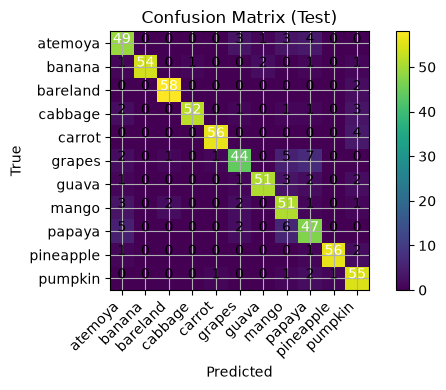

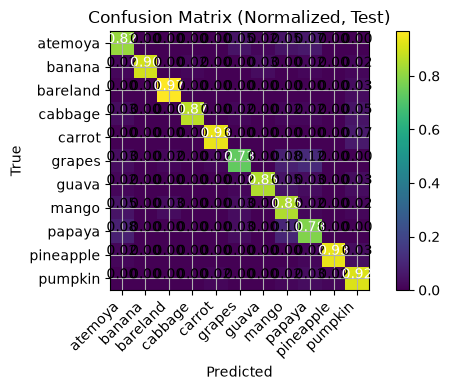


Classification Report:
              precision    recall  f1-score   support

     atemoya     0.7656    0.8167    0.7903        60
      banana     1.0000    0.9000    0.9474        60
    bareland     0.9508    0.9667    0.9587        60
     cabbage     0.9811    0.8667    0.9204        60
      carrot     0.9655    0.9333    0.9492        60
      grapes     0.8302    0.7333    0.7788        60
       guava     0.9444    0.8500    0.8947        60
       mango     0.7286    0.8500    0.7846        60
      papaya     0.7121    0.7833    0.7460        60
   pineapple     0.9825    0.9333    0.9573        60
     pumpkin     0.7857    0.9167    0.8462        60

    accuracy                         0.8682       660
   macro avg     0.8770    0.8682    0.8703       660
weighted avg     0.8770    0.8682    0.8703       660



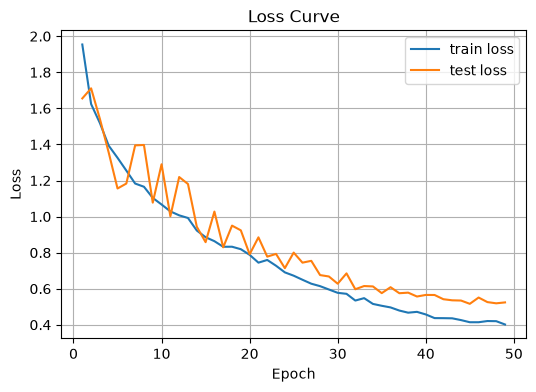

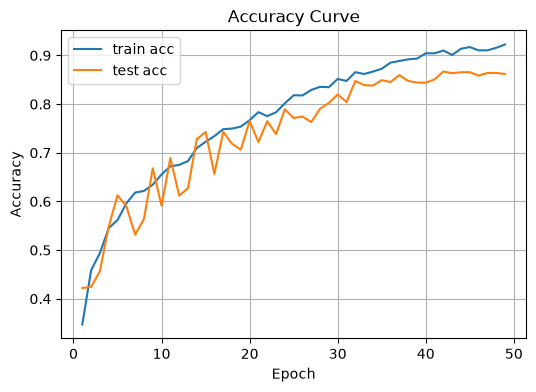

In [22]:
# 最終評估：混淆矩陣 / 報告 / 曲線
# test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device, collect=True)
test_loss, test_acc, y_true, y_pred = tta_evaluate(model, test_loader, criterion, device, tta_transforms=tta_transforms, collect=True)
print(f"[Final Test] loss={test_loss:.4f} | acc={test_acc:.4f}")

class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

def plot_cm(m, title, filename):
    plt.figure()
    plt.imshow(m, interpolation='nearest')
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha='right')
    plt.yticks(ticks, class_names)

    fmt = '.2f' if m.dtype != int and m.max() <= 1 else 'd'
    thresh = m.max() / 2

    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            plt.text(
                j, i,
                format(m[i, j], fmt),
                ha="center",
                color="white" if m[i, j] > thresh else "black"
            )

    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_cm(cm,
        "Confusion Matrix (Test)",
        "figures/confusion_matrix_test.png")

plot_cm(cm_norm,
        "Confusion Matrix (Normalized, Test)",
        "figures/confusion_matrix_normalized.png")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 學習曲線
epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(); plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["test_loss"], label="test loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.title("Loss Curve"); 
plt.savefig("figures/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(); plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.title("Accuracy Curve"); 
plt.savefig("figures/accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]c:\Users\USERYA\Desktop\pythonGit\crop-image-classification-cnn\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[Final Test] loss=0.3511 | acc=0.9435


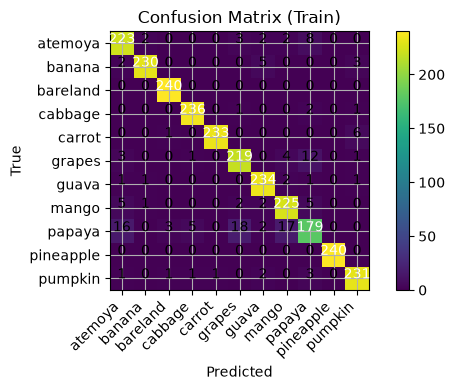

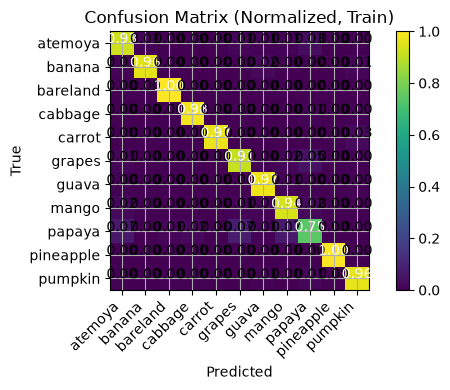


Classification Report:
              precision    recall  f1-score   support

     atemoya     0.8884    0.9292    0.9084       240
      banana     0.9829    0.9583    0.9705       240
    bareland     0.9796    1.0000    0.9897       240
     cabbage     0.9712    0.9833    0.9772       240
      carrot     0.9957    0.9708    0.9831       240
      grapes     0.9012    0.9125    0.9068       240
       guava     0.9474    0.9750    0.9610       240
       mango     0.9000    0.9375    0.9184       240
      papaya     0.8524    0.7458    0.7956       240
   pineapple     1.0000    1.0000    1.0000       240
     pumpkin     0.9506    0.9625    0.9565       240

    accuracy                         0.9432      2640
   macro avg     0.9427    0.9432    0.9425      2640
weighted avg     0.9427    0.9432    0.9425      2640



In [24]:
# 最終評估：混淆矩陣 / 報告 / 曲線
train_loss, train_acc, y_true, y_pred = evaluate(model, train_loader, criterion, device, collect=True)
print(f"[Final Test] loss={train_loss:.4f} | acc={train_acc:.4f}")

class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plot_cm(
    cm,
    "Confusion Matrix (Train)",
    "figures/confusion_matrix_train.png"
)

plot_cm(
    cm_norm,
    "Confusion Matrix (Normalized, Train)",
    "figures/confusion_matrix_train_normalized.png"
)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))